# Analise Macroeconomica — Brasil

Analise do cenario macroeconomico brasileiro com dados reais do BCB, IBGE e analyzers.

Fontes:
- **BCBFetcher**: Selic, CDI, IPCA, IGP-M, PTAX, TR, INPC, poupanca
- **IBGEFetcher**: PIB, desemprego, producao industrial
- **FiscalAnalyzer**: divida/PIB, resultado primario, trajetoria fiscal
- **CurrencyAnalyzer**: USD/BRL, carry trade, cambio real efetivo

**Nota**: Este notebook faz chamadas reais a APIs publicas (BCB, IBGE). Nao requer API keys.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14

## 1. Politica Monetaria — Selic e CDI

A taxa Selic e a principal ferramenta de politica monetaria do BCB.
O CDI acompanha de perto a Selic e serve como benchmark para renda fixa.

In [2]:
from carteira_auto.data.fetchers import BCBFetcher

bcb = BCBFetcher()

# Selic meta — serie historica de 5 anos
selic = bcb.get_selic(period_days=5 * 365)
print(f"Selic atual: {selic['valor'].iloc[-1]:.2f}% a.a.")
print(f"Periodo: {selic['data'].iloc[0].date()} a {selic['data'].iloc[-1].date()}")
print(f"Registros: {len(selic)}")

Selic atual: 14.75% a.a.
Periodo: 2021-03-27 a 2026-03-26
Registros: 1826


CDI atual: 0.0543% a.d.


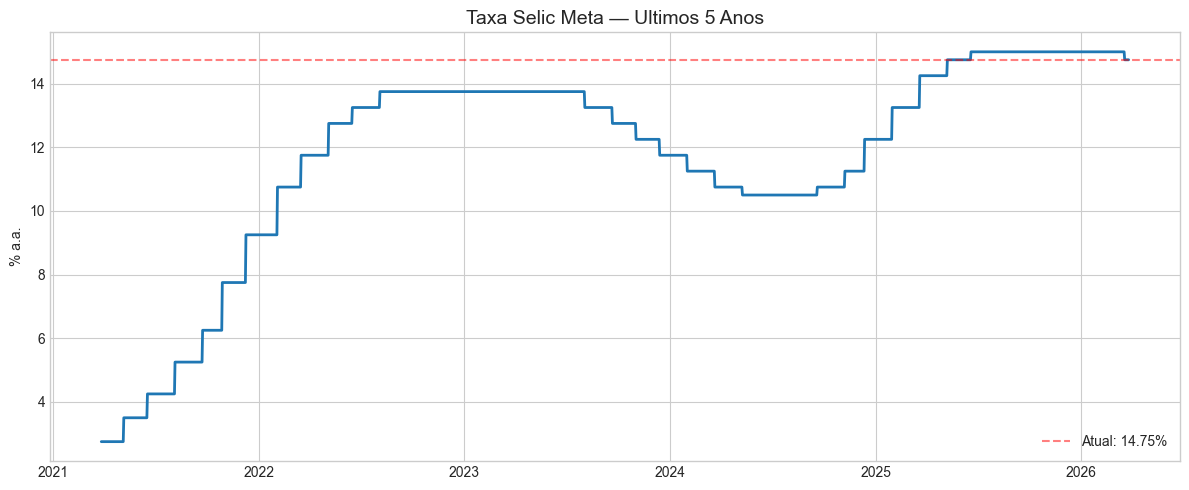

In [3]:
# CDI
cdi = bcb.get_cdi(period_days=5 * 365)
print(f"CDI atual: {cdi['valor'].iloc[-1]:.4f}% a.d.")

# Visualizar Selic
fig, ax = plt.subplots()
ax.plot(selic["data"], selic["valor"], linewidth=2, color="#1f77b4")
ax.set_title("Taxa Selic Meta — Ultimos 5 Anos")
ax.set_ylabel("% a.a.")
ax.axhline(y=selic["valor"].iloc[-1], color="red", linestyle="--", alpha=0.5,
           label=f"Atual: {selic['valor'].iloc[-1]:.2f}%")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Inflacao — IPCA e IGP-M

In [4]:
# IPCA mensal
ipca = bcb.get_ipca(period_days=3 * 365)
igpm = bcb.get_igpm(period_days=3 * 365)

print(f"IPCA ultimo mes: {ipca['valor'].iloc[-1]:.2f}%")
print(f"IGP-M ultimo mes: {igpm['valor'].iloc[-1]:.2f}%")

# IPCA acumulado 12 meses
ipca_12m = ipca.tail(12)
ipca_acum = ((1 + ipca_12m["valor"] / 100).prod() - 1) * 100
print(f"\nIPCA acumulado 12m: {ipca_acum:.2f}%")

IPCA ultimo mes: 0.70%
IGP-M ultimo mes: -0.73%

IPCA acumulado 12m: 3.81%


In [ ]:
# Visualizar IPCA mensal — barras por mês
fig, ax = plt.subplots()
colors = ["#d62728" if v > 0 else "#2ca02c" for v in ipca["valor"]]
ax.bar(range(len(ipca)), ipca["valor"], color=colors, alpha=0.8, width=0.8)

# Eixo x: rótulos mensais (MMM/YY)
labels = ipca["data"].dt.strftime("%b/%y")
ax.set_xticks(range(0, len(ipca), 3))
ax.set_xticklabels(labels.iloc[::3], rotation=45, ha="right")

ax.set_title("IPCA Mensal — Últimos 3 Anos")
ax.set_ylabel("% mensal")
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# IPCA acumulado 12 meses (rolling)
ipca_rolling = ipca.copy()
ipca_rolling["acum_12m"] = (
    (1 + ipca_rolling["valor"] / 100).rolling(12).apply(lambda x: x.prod() - 1) * 100
)
ipca_rolling = ipca_rolling.dropna(subset=["acum_12m"])

fig, ax = plt.subplots()
ax.plot(ipca_rolling["data"], ipca_rolling["acum_12m"], linewidth=2, color="#d62728")
ax.axhline(y=3.0, color="green", linestyle="--", alpha=0.6, label="Centro da meta (3.0%)")
ax.axhspan(1.5, 4.5, alpha=0.08, color="green", label="Banda da meta")
ax.set_title("IPCA Acumulado 12 Meses vs Meta de Inflação")
ax.set_ylabel("% acum. 12m")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# IPCA vs IGP-M — comparativo de inflação
fig, ax = plt.subplots()
ax.plot(ipca["data"], ipca["valor"], label="IPCA", linewidth=2, color="#d62728")
ax.plot(igpm["data"], igpm["valor"], label="IGP-M", linewidth=2, color="#ff7f0e")
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("IPCA vs IGP-M — Variação Mensal")
ax.set_ylabel("% mensal")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Cambio — USD/BRL e PTAX

In [ ]:
# PTAX compra (serie de 2 anos)
ptax = bcb.get_ptax(period_days=2 * 365)
print(f"PTAX atual: R$ {ptax['valor'].iloc[-1]:.4f}")

# Variacao 12m
if len(ptax) >= 252:
    var_12m = (ptax["valor"].iloc[-1] / ptax["valor"].iloc[-252] - 1) * 100
    print(f"Variação 12m: {var_12m:+.1f}%")

# Visualizar com cores dinâmicas e eixo y ajustado
fig, ax = plt.subplots()

# Cor baseada na tendência: verde se valorizou (caiu), vermelho se desvalorizou (subiu)
primeiro = ptax["valor"].iloc[0]
ultimo = ptax["valor"].iloc[-1]
cor_principal = "#2ca02c" if ultimo <= primeiro else "#d62728"
label_tend = "Valorização BRL" if ultimo <= primeiro else "Desvalorização BRL"

ax.plot(ptax["data"], ptax["valor"], linewidth=1.5, color=cor_principal, label=label_tend)
ax.fill_between(ptax["data"], ptax["valor"], alpha=0.1, color=cor_principal)

# Eixo y ajustado ao range real dos dados (não começa em 0)
y_min = ptax["valor"].min() * 0.98
y_max = ptax["valor"].max() * 1.02
ax.set_ylim(y_min, y_max)

ax.axhline(y=ultimo, color="gray", linestyle="--", alpha=0.5,
           label=f"Atual: R$ {ultimo:.2f}")
ax.set_title("PTAX Compra (USD/BRL) — Últimos 2 Anos")
ax.set_ylabel("R$/USD")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Atividade Economica — PIB e Desemprego

In [7]:
from carteira_auto.data.fetchers import IBGEFetcher

ibge = IBGEFetcher()

# PIB trimestral
pib = ibge.get_pib(quarters=12)
print(f"PIB: {len(pib)} trimestres")
print(pib.tail(4))

PIB: 12 trimestres
    valor periodo_codigo            periodo  \
8     3.1         202501  1º trimestre 2025   
9     2.4         202502  2º trimestre 2025   
10    1.8         202503  3º trimestre 2025   
11    1.8         202504  4º trimestre 2025   

                                             variavel  \
8   Taxa trimestral (em relação ao mesmo período d...   
9   Taxa trimestral (em relação ao mesmo período d...   
10  Taxa trimestral (em relação ao mesmo período d...   
11  Taxa trimestral (em relação ao mesmo período d...   

                      grupo unidade  
8   PIB a preços de mercado       %  
9   PIB a preços de mercado       %  
10  PIB a preços de mercado       %  
11  PIB a preços de mercado       %  


In [8]:
# Desemprego (PNAD Continua)
desemprego = ibge.get_unemployment(quarters=12)
print(f"Desemprego: {len(desemprego)} trimestres")
print(desemprego.tail(4))

Desemprego: 12 trimestres
    valor periodo_codigo periodo
8     5.4         202510  202510
9     5.2         202511  202511
10    5.1         202512  202512
11    5.4         202601  202601


In [ ]:
# Visualizar PIB e Desemprego lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PIB trimestral
colors_pib = ["#2ca02c" if v >= 0 else "#d62728" for v in pib["valor"]]
ax1.bar(range(len(pib)), pib["valor"], color=colors_pib, alpha=0.8, width=0.7)
ax1.set_xticks(range(len(pib)))
ax1.set_xticklabels(pib["periodo_codigo"], rotation=45, ha="right", fontsize=8)
ax1.set_title("PIB — Variação Trimestral YoY")
ax1.set_ylabel("% vs mesmo trimestre ano anterior")
ax1.axhline(y=0, color="black", linewidth=0.5)

# Desemprego
ax2.plot(range(len(desemprego)), desemprego["valor"], "o-", linewidth=2,
         markersize=6, color="#1f77b4")
ax2.fill_between(range(len(desemprego)), desemprego["valor"], alpha=0.1, color="#1f77b4")
ax2.set_xticks(range(len(desemprego)))
ax2.set_xticklabels(desemprego["periodo_codigo"], rotation=45, ha="right", fontsize=8)
ax2.set_title("Taxa de Desocupação — PNAD Contínua")
ax2.set_ylabel("% da PEA")

# Ajustar eixo y para visualizar melhor
y_min = desemprego["valor"].min() * 0.9
y_max = desemprego["valor"].max() * 1.1
ax2.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

## 5. Juros Reais — Selic vs IPCA

In [9]:
# Juro real = Selic - IPCA acum. 12m (aproximacao)
selic_atual = selic["valor"].iloc[-1]
juro_real = selic_atual - ipca_acum

print(f"Selic: {selic_atual:.2f}% a.a.")
print(f"IPCA 12m: {ipca_acum:.2f}%")
print(f"Juro real aproximado: {juro_real:.2f}% a.a.")
print(f"\nInterpretacao: {'Restritivo' if juro_real > 3 else 'Neutro' if juro_real > 0 else 'Expansionista'}")

Selic: 14.75% a.a.
IPCA 12m: 3.81%
Juro real aproximado: 10.94% a.a.

Interpretacao: Restritivo


In [ ]:
# Visualizar comparativo: Selic nominal vs IPCA 12m vs Juro Real
fig, ax = plt.subplots(figsize=(8, 5))

categorias = ["Selic nominal", "IPCA 12m", "Juro real"]
valores = [selic_atual, ipca_acum, juro_real]
cores = ["#1f77b4", "#d62728", "#2ca02c"]

bars = ax.bar(categorias, valores, color=cores, alpha=0.85, width=0.5)
for bar, val in zip(bars, valores, strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=12)

ax.set_title("Selic Nominal vs IPCA vs Juro Real")
ax.set_ylabel("% a.a.")
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 6. Analise Fiscal — FiscalAnalyzer

O FiscalAnalyzer busca 5 series do BCB e classifica a trajetoria fiscal
com gradacao: stable → warning → critical → severe.

In [ ]:
# Painel fiscal visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Composição fiscal (% do PIB)
labels_fiscal = ["Dív. bruta", "Dív. líquida", "Juros nom.", "Res. primário"]
valores_fiscal = [
    fm.divida_bruta_pib or 0,
    fm.divida_liquida_pib or 0,
    fm.juros_nominais_pib or 0,
    fm.resultado_primario_pib or 0,
]
cores_fiscal = ["#d62728", "#ff7f0e", "#9467bd", "#2ca02c" if (fm.resultado_primario_pib or 0) > 0 else "#d62728"]

bars = ax1.barh(labels_fiscal, valores_fiscal, color=cores_fiscal, alpha=0.85)
for bar, val in zip(bars, valores_fiscal, strict=False):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontweight="bold")
ax1.set_title("Indicadores Fiscais (% do PIB)")
ax1.set_xlabel("% do PIB")

# Faixas de risco da dívida bruta/PIB
divida = fm.divida_bruta_pib or 0
faixas = [75, 80, 85, 100]
faixa_labels = ["Estável\n(<75%)", "Atenção\n(75-80%)", "Crítico\n(80-85%)", "Severo\n(>85%)"]
faixa_cores = ["#2ca02c", "#ff7f0e", "#d62728", "#8b0000"]

ax2.barh(faixa_labels, faixas, color=faixa_cores, alpha=0.3, height=0.6)
ax2.axvline(x=divida, color="black", linewidth=3, linestyle="-",
            label=f"Atual: {divida:.1f}%")
ax2.set_title(f"Dívida Bruta/PIB — Trajetória: {fm.fiscal_trajectory}")
ax2.set_xlabel("% do PIB")
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
from carteira_auto.analyzers import FiscalAnalyzer
from carteira_auto.core.engine import PipelineContext

fiscal = FiscalAnalyzer()
ctx = PipelineContext()
ctx = fiscal.run(ctx)

fm = ctx["fiscal_metrics"]
print("=== Metricas Fiscais ===")
print(f"Divida bruta/PIB: {fm.divida_bruta_pib}%")
print(f"Divida liquida/PIB: {fm.divida_liquida_pib}%")
print(f"Resultado primario/PIB: {fm.resultado_primario_pib}%")
print(f"Juros nominais/PIB: {fm.juros_nominais_pib}%")
print(f"Variacao divida 12m: {fm.divida_bruta_pib_change_12m} pp")
print(f"Trajetoria: {fm.fiscal_trajectory}")
print(f"\nSumario: {fm.summary}")

2026-03-26 18:13:36 INFO     carteira_auto.analyzers.fiscal_analyzer: Fiscal: dívida          ]8;id=950517;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/analyzers/fiscal_analyzer.py\fiscal_analyzer.py]8;;\:]8;id=862269;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/analyzers/fiscal_analyzer.py#45\45]8;;\
                             bruta=78.73% PIB, primário=0.43% PIB, trajetória=warning                              

=== Metricas Fiscais ===
Divida bruta/PIB: 78.73%
Divida liquida/PIB: 56.38%
Resultado primario/PIB: 0.43%
Juros nominais/PIB: 8.48%
Variacao divida 12m: 3.26 pp
Trajetoria: warning

Sumario: Dívida bruta 78.7% PIB; primário +0.43% PIB; juros 8.5% PIB; trajetória=warning


## 7. Analise Cambial — CurrencyAnalyzer

O CurrencyAnalyzer busca PTAX, DXY, Selic e Fed Funds
para calcular carry spread e tendencia cambial.

**Nota**: requer `FRED_API_KEY` para Fed Funds Rate. Sem a key, carry_spread sera None.

In [11]:
from carteira_auto.analyzers import CurrencyAnalyzer

currency = CurrencyAnalyzer()
ctx = PipelineContext()
ctx = currency.run(ctx)

cm = ctx["currency_metrics"]
print("=== Metricas Cambiais ===")
print(f"USD/BRL (PTAX): R$ {cm.usd_brl}")
print(f"Variacao 1m: {cm.usd_brl_change_1m}%")
print(f"Variacao 3m: {cm.usd_brl_change_3m}%")
print(f"Variacao 12m: {cm.usd_brl_change_12m}%")
print(f"DXY: {cm.dxy}")
print(f"Selic: {cm.selic_rate}% | Fed Funds: {cm.fed_funds_rate}%")
print(f"Carry spread: {cm.carry_spread} pp")
print(f"Cambio real efetivo: {cm.taxa_cambio_real_efetiva}")
print(f"\nSumario: {cm.summary}")

/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/venv/lib/python3.12/site-packages/yfinance/utils.py:167: DeprecationWarning: enable_debug_mode() is replaced by: yf.config.debug.logging = True (or False to disable)
  warnings.warn("enable_debug_mode() is replaced by: yf.config.debug.logging = True (or False to disable)", DeprecationWarning)


2026-03-26 18:15:00 INFO     carteira_auto.data.fetchers.yahoo_fetcher: Modo debug do yfinance  ]8;id=438589;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=684368;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#49\49]8;;\
                             ativado                                                                               

                    INFO     carteira_auto.data.fetchers.yahoo_fetcher: YahooFinanceFetcher     ]8;id=370295;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=81302;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#39\39]8;;\
                             inicializado: workers=12, timeout=30s, retries=3                                      

2026-03-26 18:15:03 ERROR    carteira_auto.analyzers.currency_analyzer: Falha ao buscar     ]8;id=772720;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/analyzers/currency_analyzer.py\currency_analyzer.py]8;;\:]8;id=406826;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/analyzers/currency_analyzer.py#90\90]8;;\
                             DXY: Ticker inválido: DX-Y.NYB                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto                        
                             /src/carteira_auto/analyzers/currency_analyzer.py", line 83,                          
                             in _build_currency_metrics                                                            
                                 dxy_data = yahoo.get_historical_price_data("DX-Y.NYB",                            
                             period="3mo")                                                                         
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                        
                             ^^^^^^^^^^                                                                            
                               File                                                                                
                             "/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto                        
                             /src/carteira_auto/utils/decorators.py", line 48, in wrapper                          
                                 raise last_exception                                                              
                               File                                                                                
                             "/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto                        
                             /src/carteira_auto/utils/decorators.py", line 43, in wrapper                          
                                 return func(*args, **kwargs)                                                      
                                        ^^^^^^^^^^^^^^^^^^^^^                                                      
                               File                                                                                
                             "/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto                        
                             /src/carteira_auto/utils/decorators.py", line 71, in wrapper                          
                                 return func(*args, **kwargs)                                                      
                                        ^^^^^^^^^^^^^^^^^^^^^                                                      
                               File                                                                                
                             "/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto                        
                             /src/carteira_auto/utils/decorators.py", line 95, in wrapper                          
                                 result = func(*args, **kwargs)                                                    
                                          ^^^^^^^^^^^^^^^^^^^^^                                                    
                               File                                                                                
                             "/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto                      

                    INFO     carteira_auto.data.fetchers.fred_fetcher: FRED: DFF — 3737         ]8;id=590986;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/fred_fetcher.py\fred_fetcher.py]8;;\:]8;id=1692;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/fred_fetcher.py#211\211]8;;\
                             observações (2016-01-01 → 2026-03-26)                                                 

2026-03-26 18:15:05 INFO     carteira_auto.analyzers.currency_analyzer: Câmbio:             ]8;id=361109;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/analyzers/currency_analyzer.py\currency_analyzer.py]8;;\:]8;id=133360;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/analyzers/currency_analyzer.py#35\35]8;;\
                             USD/BRL=5.2302, DXY=None, carry=11.11pp                                               

=== Metricas Cambiais ===
USD/BRL (PTAX): R$ 5.2302
Variacao 1m: 1.69%
Variacao 3m: -5.99%
Variacao 12m: -8.71%
DXY: None
Selic: 14.75% | Fed Funds: 3.64%
Carry spread: 11.11 pp
Cambio real efetivo: 123.71

Sumario: USD/BRL R$5.23; carry +11.11pp; câmbio real 123.7


## 8. MacroAnalyzer — Contexto Consolidado

O MacroAnalyzer consolida 11 indicadores macro em um unico `MacroContext`.

In [ ]:
from carteira_auto.analyzers import MacroAnalyzer

macro = MacroAnalyzer()
ctx = PipelineContext()
ctx = macro.run(ctx)

mc = ctx["macro_context"]
print("=== Contexto Macro Consolidado ===")
print(f"Selic: {mc.selic}% | CDI: {mc.cdi:.2f}%")
print(f"IPCA: {mc.ipca:.2f}% | IGP-M: {mc.igpm:.2f}%")
print(f"PTAX: R$ {mc.cambio}")
print(f"Poupança: {mc.poupanca:.2f}% | TR: {mc.tr:.2f}%")
print(f"PIB crescimento: {mc.pib_growth}%")
print(f"Desocupação: {mc.desocupacao}%")
print(f"\nSumário: {mc.summary}")

# Erros parciais (se houve falhas)
if ctx.has_errors:
    print(f"\nErros parciais: {ctx.errors}")

## Resumo do Cenario Macro

Os dados acima permitem avaliar:

| Dimensao | Indicadores | Analise |
|----------|-------------|---------|
| **Politica monetaria** | Selic, CDI, juro real | Restritivo se juro real > 3% |
| **Inflacao** | IPCA, IGP-M | Dentro da meta? Tendencia? |
| **Cambio** | PTAX, DXY, carry | Apreciacao ou depreciacao do BRL? |
| **Atividade** | PIB, desemprego | Ciclo de expansao ou contracao? |
| **Fiscal** | Divida/PIB, primario | Trajetoria sustentavel? |